<a href="https://colab.research.google.com/github/Shojaiaa/Time-Series-Analysis/blob/main/Resampling_Datetime_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [41]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/02-IntroML/london_weather.csv'

In [3]:
# Load the dataset
df = pd.read_csv(fpath)
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [4]:
# Check the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


## Creating a Datetime Index

The date values are converted into datetime format, and the new datetime column is set as the index to enable time-based filtering and resampling.

In [5]:
# Convert the date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

In [6]:
# Create a new datetime column
df['datetime'] = pd.to_datetime(df['date'], format='%Y%m%d')

In [7]:
# Set datetime as the index
df = df.set_index('datetime')

In [8]:
# Check the result
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
datetime,,,,,,,,,,
1979-01-01,1979-01-01,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1979-01-02,1979-01-02,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
1979-01-03,1979-01-03,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
1979-01-04,1979-01-04,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
1979-01-05,1979-01-05,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


## Filtering the Required Data

The data is limited to the year 2000 or later, and only the required weather features are retained.

In [9]:
# Keep data from 2000 or later
df = df.loc['2000':]

In [10]:
# Keep only the required columns
df = df[
    ['precipitation',
     'mean_temp',
     'min_temp',
     'max_temp',
     'snow_depth']
]

In [11]:
# Display the filtered data
df.head()

,precipitation,mean_temp,min_temp,max_temp,snow_depth
datetime,,,,,
2000-01-01,0.0,7.0,4.9,10.8,0.0
2000-01-02,0.2,7.9,5.0,11.5,0.0
2000-01-03,6.0,9.4,7.2,9.5,0.0
2000-01-04,0.2,7.0,4.4,11.0,0.0
2000-01-05,0.8,6.4,1.9,10.8,0.0


In [12]:
# Check the first and last dates
print(df.index.min())
print(df.index.max())

2000-01-01 00:00:00
2020-12-31 00:00:00


In [13]:
# Check the number of missing values
df.isna().sum()

,0
precipitation,6
mean_temp,36
min_temp,2
max_temp,6
snow_depth,1441


## Handling Missing Values

Interpolation is used for temperature and precipitation because it estimates missing values from nearby dates. Missing snow depth values are replaced with zero.

In [14]:
# Fill missing weather values using interpolation
weather_columns = [
    'precipitation',
    'mean_temp',
    'min_temp',
    'max_temp'
]

df[weather_columns] = df[weather_columns].interpolate()

In [15]:
# Fill missing snow depth values with 0
df['snow_depth'] = df['snow_depth'].fillna(0)

In [16]:
# Confirm that all missing values were filled
df.isna().sum()

,0
precipitation,0
mean_temp,0
min_temp,0
max_temp,0
snow_depth,0


## Monthly Precipitation Analysis (2000–2010)

The precipitation data is resampled from daily to monthly frequency. The daily values are summed to calculate the total precipitation for each month and identify the month with the highest precipitation.

In [17]:
# Selecting precipitation data from 2000 through 2010
q1 = df.loc['2000':'2010', ['precipitation']]

In [18]:
# Resampling precipitation to monthly frequency
q1_monthly = q1.resample('MS').sum()

In [19]:
# Displaying the monthly precipitation data
q1_monthly.head()

,precipitation
datetime,
2000-01-01,16.5
2000-02-01,62.2
2000-03-01,16.0
2000-04-01,99.6
2000-05-01,87.2


In [20]:
# Identifying the month with the highest precipitation
max_precipitation_date = q1_monthly['precipitation'].idxmax()

In [21]:
# Identifying the highest precipitation value
max_precipitation = q1_monthly['precipitation'].max()

In [22]:
print(max_precipitation_date)
print(max_precipitation)

2000-10-01 00:00:00
155.4


### Visualizing Monthly Precipitation

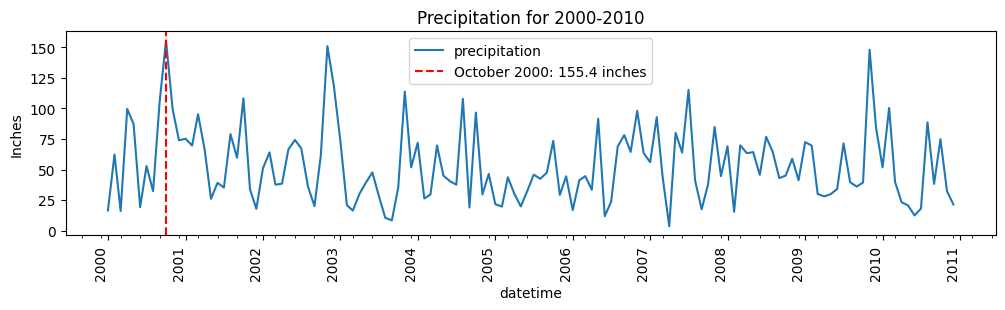

In [24]:
# Creating the figure
fig, ax = plt.subplots(figsize=(12, 3))

# Plotting monthly precipitation
q1_monthly.plot(ax=ax, x_compat=True)

# Adding the title and y-axis label
ax.set_title('Precipitation for 2000-2010')
ax.set_ylabel('Inches')

# Formatting the major x-axis ticks
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Formatting the minor x-axis ticks
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax.tick_params(axis='x', which='minor', labelbottom=False)

# Formatting the maximum precipitation date
max_date_label = max_precipitation_date.strftime('%B %Y')

# Adding a vertical line at the maximum precipitation date
ax.axvline(
    max_precipitation_date,
    color='red',
    linestyle='--',
    label=f'{max_date_label}: {max_precipitation} inches'
)

# Adding the legend
ax.legend()

# Rotating the year labels
fig.autofmt_xdate(which='major', rotation=90)

plt.show()

October 2000 had the highest monthly precipitation between 2000 and 2010, with a total precipitation of 155.4 inches.

## Yearly Average Temperature Analysis (2000–2020)

The mean temperature data is resampled from daily to yearly frequency. The yearly average is calculated to identify the year with the lowest average temperature.

In [26]:
# Selecting mean temperature data from 2000 through 2020
q2 = df.loc['2000':'2020', ['mean_temp']]

In [28]:
# Resampling mean temperature to yearly frequency
q2_yearly = q2.resample('YS').mean()

In [39]:
# Displaying the yearly average temperature
q2_yearly.head(21)

,mean_temp
datetime,
2000-01-01,11.582514
2001-01-01,11.339452
2002-01-01,12.084384
2003-01-01,12.138356
2004-01-01,11.868579
2005-01-01,11.825479
2006-01-01,12.299589
2007-01-01,11.926575
2008-01-01,11.347268


In [34]:
# Identifying the year with the lowest average temperature
min_temperature_date = q2_yearly['mean_temp'].idxmin()

In [35]:
# Identifying the lowest average temperature
min_temperature = q2_yearly['mean_temp'].min()

In [36]:
print(min_temperature_date)
print(min_temperature)

2010-01-01 00:00:00
10.635890410958904


### Visualizing Yearly Average Temperature

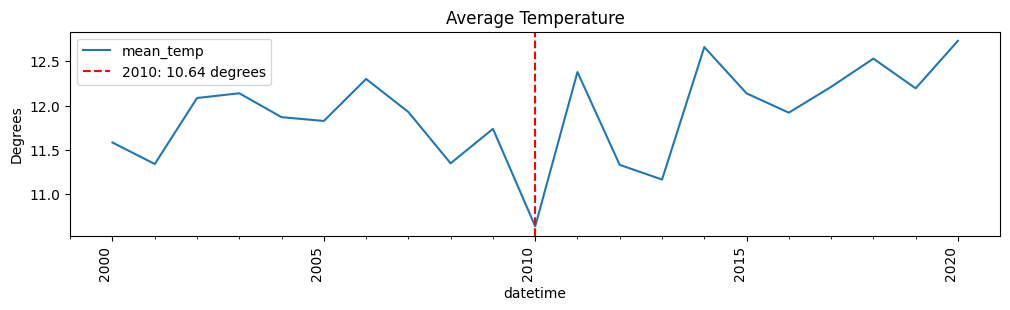

In [40]:
# Creating the figure
fig, ax = plt.subplots(figsize=(12, 3))

# Plotting yearly average temperature
q2_yearly.plot(ax=ax, x_compat=True)

# Adding the title and y-axis label
ax.set_title('Average Temperature')
ax.set_ylabel('Degrees')

# Formatting the major x-axis ticks
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Formatting the minor x-axis ticks
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.tick_params(axis='x', which='minor', labelbottom=False)

# Formatting the minimum temperature date
min_date_label = min_temperature_date.strftime('%Y')

# Adding a vertical line at the minimum temperature date
ax.axvline(
    min_temperature_date,
    color='red',
    linestyle='--',
    label=f'{min_date_label}: {min_temperature:.2f} degrees'
)

# Adding the legend
ax.legend()

# Rotating the year labels
fig.autofmt_xdate(which='major', rotation=90)

plt.show()

The year 2010 had the lowest average temperature between 2000 and 2020, with an average temperature of approximately 10.64 degrees.